<a href="https://colab.research.google.com/github/SaiSiri05/MachineLearning_Labs/blob/main/AIML_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART 1

In [ ]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=c75edf4daf1e8ded655e1c6a4920fc5f6a934ca7a3d2b2df555586d289c2e071
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [ ]:
wikipedia.set_lang('en')

eng_ai = wikipedia.page("Artificial intelligence").content
eng_ww2 = wikipedia.page("World War II").content


wikipedia.set_lang('de')

ger_ai = wikipedia.page("Künstliche Intelligenz").content
ger_ww2 = wikipedia.page("Zweiter Weltkrieg").content

In [ ]:
eng_ww2

'World War I, or the First World War (28 July 1914 – 11 November 1918), also known as the Great War, was a global conflict between two coalitions: the Allies (or Entente) and the Central Powers. Major areas of conflict included Europe and the Middle East, as well as parts of Africa and the Asia-Pacific. The war saw important developments in weaponry including tanks, aircraft, artillery, machine guns, and chemical weapons. One of the deadliest conflicts in history, it resulted in an estimated 30 million military casualties, and 8 million civilian deaths from war-related causes and genocide. The movement of large numbers of people was a major factor in the deadly Spanish flu pandemic. \nThe causes of World War I included the rise of the German Empire and decline of the Ottoman Empire, which disturbed the long-standing balance of power in Europe, the exacerbation of imperial rivalries, and an arms race between the great powers. Growing tensions in the Balkans reached a breaking point on 2

In [ ]:
ger_ww2

'Als Zweiter Weltkrieg (1. September 1939 – 2. September 1945) wird der zweite global geführte Krieg sämtlicher Großmächte im 20. Jahrhundert bezeichnet. Über 60 Staaten waren direkt oder indirekt beteiligt, mehr als 110 Millionen Menschen trugen Waffen. Schätzungen zufolge wurden über 65 Millionen Menschen getötet.\nIn Europa begann der Zweite Weltkrieg am 1. September 1939 mit dem von Adolf Hitler befohlenen Überfall auf Polen. In Ostasien befand sich das Kaiserreich Großjapan unter Kaiser Hirohito bereits seit Juli 1937 im Zweiten Japanisch-Chinesischen Krieg mit der Republik China und ab Mitte 1938 in einem Grenzkrieg mit der Sowjetunion. Der japanische Angriff auf Pearl Harbor Anfang Dezember 1941 eröffnete den Pazifikkrieg. Japan erklärte am selben Tag den Vereinigten Staaten und Großbritannien den Krieg. Kriegserklärungen Deutschlands und Italiens an die USA folgten kurz darauf.\nIm Kriegsverlauf bildeten sich zwei militärische Allianzen, die als Achsenmächte und Alliierte (Anti

In [ ]:
# Function to clean text
def cleanup(text):
    # Convert all characters to lowercase
    text = text.lower()

    # Remove everything except letters a-z
    text = re.sub('[^a-z]+', '', text)

    return text

In [ ]:
# Clean all articles before analysis
eng_ai = cleanup(eng_ai)
eng_ww2 = cleanup(eng_ww2)
ger_ai = cleanup(ger_ai)
ger_ww2 = cleanup(ger_ww2)

print(eng_ai)
print(ger_ai)

...


converting


In [ ]:
# Create unigram (single-letter) frequency counters
# ngrams(text,1) generates 1-letter sequences
# Counter counts how many times each letter appears

unigram_eng_ai = Counter(ngrams(eng1,1))
unigram_eng_ww2 = Counter(ngrams(eng2,1))
unigram_ger_ai = Counter(ngrams(fr1,1))
unigram_ger_ww2 = Counter(ngrams(fr2,1))

# Display English AI unigram frequencies
print(unigram_eng_ai)

Counter({('e',): 3987, ('a',): 2985, ('t',): 2549, ('i',): 2462, ('s',): 2283, ('n',): 2149, ('o',): 2123, ('r',): 2114, ('h',): 1470, ('l',): 1406, ('d',): 1171, ('f',): 1087, ('c',): 1020, ('g',): 972, ('m',): 831, ('u',): 810, ('p',): 687, ('b',): 453, ('y',): 432, ('w',): 398, ('v',): 386, ('k',): 235, ('x',): 80, ('z',): 27, ('j',): 21, ('q',): 12})


In [ ]:
# Convert tuple like ('a',) → "a"
def tuple2string(tup):
    return ''.join(tup)


# Convert list of tuple keys into strings
def key2string(keys):
    return [tuple2string(i) for i in keys]

# Plot histogram of unigram frequencies
def plothistogram(ngram):
    keys = key2string(ngram.keys())
    values = list(ngram.values())

    # Sort alphabetically
    combined = zip(keys, values)
    zipped_sorted = sorted(combined, key=lambda x: x[0])
    keys, values = map(list, zip(*zipped_sorted))

    plt.bar(keys, values)

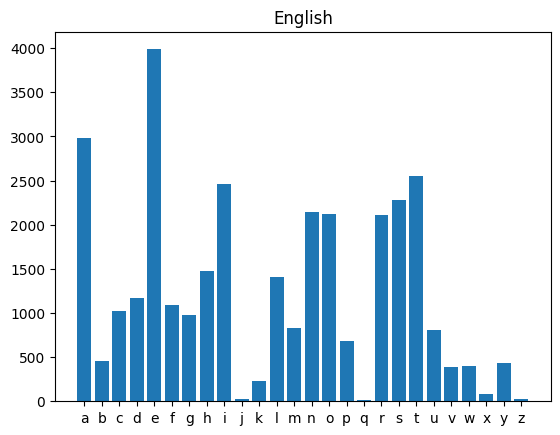

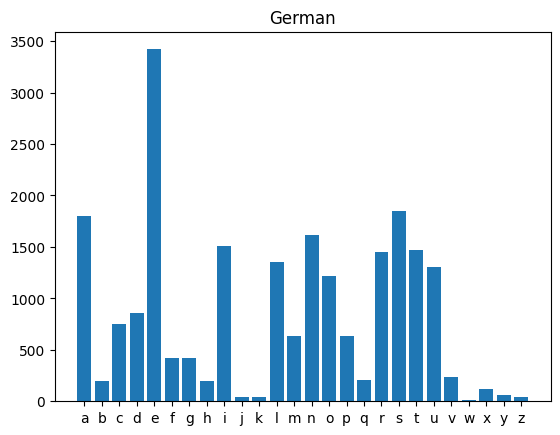

In [ ]:
# Plot English unigram distribution
plothistogram(unigram_eng_ai)
plt.title("English")
plt.show()

# Plot German unigram distribution
plothistogram(unigram_ger_ai)
plt.title("German")
plt.show()

In [ ]:
# Create trigram (3-letter sequence) frequency counters
trigram_eng_ai = Counter(ngrams(eng_ai,3))
trigram_eng_ww2 = Counter(ngrams(eng_ww2,3))
trigram_ger_ai = Counter(ngrams(ger_ai,3))
trigram_ger_ww2 = Counter(ngrams(ger_ww2,3))

In [ ]:
# Create 26x26 heatmap for bigram frequencies
def plotbihistogram(ngram):
    freq = np.zeros((26,26))

    # Fill matrix with bigram counts
    for i in range(26):
        for j in range(26):
            freq[i,j] = ngram[(chr(ord('a')+i), chr(ord('a')+j))]

    # Display heatmap
    plt.imshow(freq, cmap='jet')
    return freq

In [ ]:
# Create 2D heatmap for trigrams starting with a chosen first letter
def plottrihistogram(ngram, first_letter='a'):
    freq = np.zeros((26,26))

    for i in range(26):
        for j in range(26):
            trigram_key = (
                first_letter,
                chr(ord('a')+i),
                chr(ord('a')+j)
            )
            freq[i,j] = ngram[trigram_key]

    plt.imshow(freq, cmap='jet')
    plt.xlabel("Third Letter")
    plt.ylabel("Second Letter")
    plt.colorbar()
    return freq

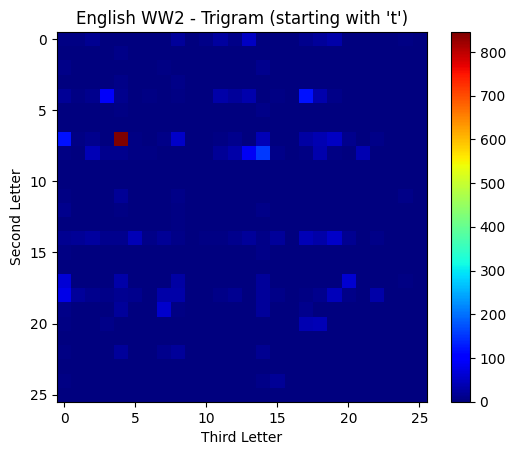

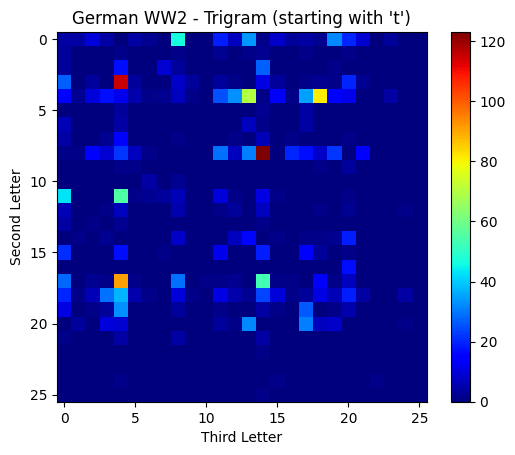

In [ ]:
# English WW2 trigrams starting with 't'
tri_eng_ww2 = plottrihistogram(trigram_eng_ww2, 't')
plt.title("English WW2 - Trigram (starting with 't')")
plt.show()

# German WW2 trigrams starting with 't'
tri_ger_ww2 = plottrihistogram(trigram_ger_ww2, 't')
plt.title("German WW2 - Trigram (starting with 't')")
plt.show()

In [ ]:
# Display Top N trigrams from heatmap
def ShowTopN_tri(trifreq, first_letter='t', n=10):
    f = trifreq.flatten()
    arg = np.argsort(-f)

    for ii in range(n):
        ind = arg[ii]
        i = int(ind/26)
        j = int(ind%26)

        second = chr(ord('a')+i)
        third = chr(ord('a')+j)

        print(f"('{first_letter}', '{second}', '{third}') : {f[ind]}")

In [ ]:
print("English WW2 Top Trigrams (starting with 't'):")
ShowTopN_tri(tri_eng_ww2, first_letter='t')

print("German WW2 Top Trigrams (starting with 'p'):")
ShowTopN_tri(tri_ger_ww2, first_letter='p')

English WW2 Top Trigrams (starting with 't'):
('t', 'h', 'e') : 845.0
('t', 'i', 'o') : 154.0
('t', 'e', 'r') : 121.0
('t', 'h', 'a') : 121.0
('t', 'e', 'd') : 91.0
('t', 'i', 'n') : 89.0
('t', 's', 'a') : 79.0
('t', 'r', 'a') : 65.0
('t', 'r', 'u') : 62.0
('t', 't', 'h') : 58.0
German WW2 Top Trigrams (starting with 'p'):
('p', 'i', 'o') : 123.0
('p', 'd', 'e') : 115.0
('p', 'r', 'e') : 91.0
('p', 'e', 's') : 81.0
('p', 'e', 'n') : 70.0
('p', 'l', 'e') : 55.0
('p', 'r', 'o') : 53.0
('p', 'a', 'i') : 47.0
('p', 'l', 'a') : 43.0
('p', 's', 'e') : 37.0


In [ ]:
# Final Conclusion:
# Unigram analysis shows basic letter distribution differences.
# Bigram heatmaps reveal common letter pair patterns.
# Trigram analysis captures deeper structural differences.
# English shows high frequency of "the".
# German shows different trigram clusters.
# N-gram statistics effectively capture linguistic structure.

PART 2

In [ ]:
# Import MNIST handwritten digit dataset
from keras.datasets import mnist

# Load training and testing data
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Select only digits 0 and 1 for binary classification
digits = [0,1]
subset = np.isin(train_y, digits)

X = train_X[subset]
y = train_y[subset]

In [ ]:
# 📌 Notes
# Computes a threshold between class 0 and class 1 mean feature values.
# If feature > threshold → classify as 1.
# Otherwise → classify as 0.
# Used to check if a single feature alone can separate classes.
# Very basic classifier (not machine learning).

# Your results are low because:
# Direction condition is reversed.
# Features overlap.

In [ ]:
# Simple statistical threshold-based classifier
def simple_threshold_classifier(feat0, feat1):
    threshold = (feat0.mean() + feat1.mean()) / 2
    pred0 = feat0 > threshold
    pred1 = feat1 > threshold

    correct0 = np.sum(pred0 == 0)
    correct1 = np.sum(pred1 == 1)

    total = len(feat0) + len(feat1)
    return (correct0 + correct1) / total

In [ ]:
import numpy as np
from scipy import ndimage
from skimage import morphology, measure

# Separate digits 0 and 1 from the main dataset (X, y)
X0 = X[y == 0]
X1 = X[y == 1]

# Feature extraction functions
def get_sum_feature(images):
    # Sum of all pixel values in each image
    return images.sum(axis=(1, 2))

def get_hole_feature(images):
    holes = []
    for img in images:
        # Convert image to binary (pixels > 0 are foreground)
        binary_img = img > 0
        # Fill holes in the binary image
        filled_img = ndimage.binary_fill_holes(binary_img)
        # Hole feature: sum of pixels in filled image - sum of pixels in original binary image
        holes.append(np.sum(filled_img) - np.sum(binary_img))
    return np.array(holes)

def get_hull_feature(images):
    hull_features = []
    for img in images:
        # Convert image to binary
        binary_img = img > 0
        # Compute the convex hull of the binary image
        hull = morphology.convex_hull_image(binary_img)
        # Hull feature: area of convex hull - area of the digit itself
        hull_features.append(np.sum(hull) - np.sum(binary_img))
    return np.array(hull_features)

def get_boundary_feature(images):
    boundary_features = []
    for img in images:
        # Convert image to binary
        binary_img = img > 0
        # Calculate the perimeter (boundary length) of the digit
        boundary_features.append(measure.perimeter(binary_img))
    return np.array(boundary_features)

# Extract features for digit 0
sum0 = get_sum_feature(X0)
hole0 = get_hole_feature(X0)
hull0 = get_hull_feature(X0)
bound0 = get_boundary_feature(X0)

# Extract features for digit 1
sum1 = get_sum_feature(X1)
hole1 = get_hole_feature(X1)
hull1 = get_hull_feature(X1)
bound1 = get_boundary_feature(X1)

# Original print statements
print("Sum accuracy:", simple_threshold_classifier(sum0, sum1))
print("Hole accuracy:", simple_threshold_classifier(hole0, hole1))
print("Hull accuracy:", simple_threshold_classifier(hull0, hull1))
print("Boundary accuracy:", simple_threshold_classifier(bound0, bound1))

Sum accuracy: 0.07153572838531386
Hole accuracy: 0.07003553099091986
Hull accuracy: 0.10904066324516384
Boundary accuracy: 0.009395973154362415


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from itertools import combinations

In [ ]:
X0 = np.column_stack((sum0, hole0, hull0, bound0))
X1 = np.column_stack((sum1, hole1, hull1, bound1))

X = np.vstack((X0, X1))
y = np.array([0]*len(X0) + [1]*len(X1))

In [ ]:
# Stack all 4 features into feature matrix
feature_names = ["Sum", "Hole", "Hull", "Boundary"]

for comb in combinations(range(4), 2):
    X_sub = X[:, comb]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y, test_size=0.3, random_state=42
    )

    model = LogisticRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    print(feature_names[comb[0]], "+", feature_names[comb[1]], ":", acc)

Sum + Hole : 0.9868421052631579
Sum + Hull : 0.9660526315789474
Sum + Boundary : 0.99
Hole + Hull : 0.9810526315789474
Hole + Boundary : 0.9944736842105263
Hull + Boundary : 0.9918421052631579


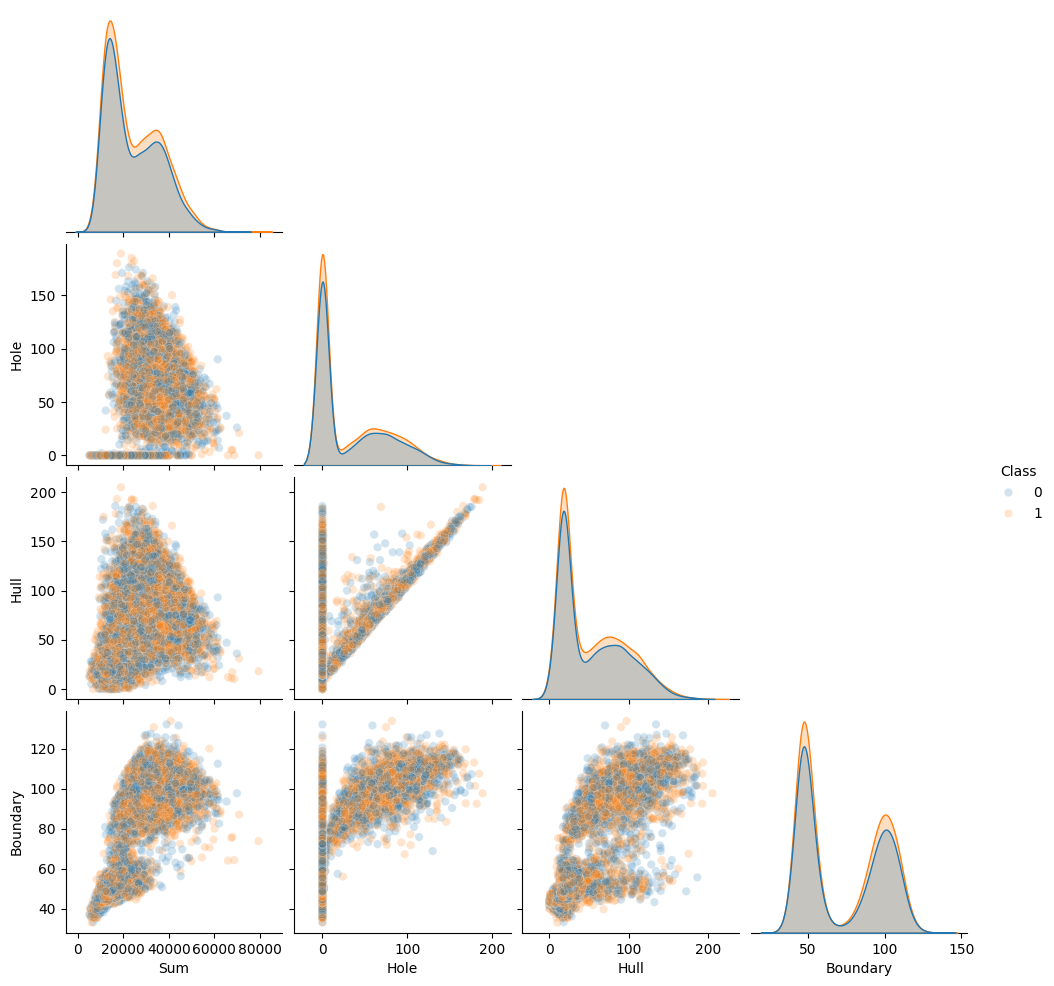

In [ ]:
import seaborn as sns
import numpy as np

# Reconstruct the feature matrix from X0 and X1 for plotting
X_features = np.vstack((X0, X1))

df = pd.DataFrame(X_features, columns=["Sum","Hole","Hull","Boundary"])
df["Class"] = y

sns.pairplot(df, hue="Class", corner=True, plot_kws={'alpha':0.2})
plt.show()

In [ ]:
# Extend problem to 3 classes
digits = [0,1,2]
subset = np.isin(train_y, digits)

X_multi = train_X[subset]
y_multi = train_y[subset]

In [ ]:
# Train logistic regression on 3 classes
sum_feat = get_sum_feature(X_multi)
hole_feat = get_hole_feature(X_multi)
hull_feat = get_hull_feature(X_multi)
bound_feat = get_boundary_feature(X_multi)

features_multi = np.column_stack((sum_feat, hole_feat, hull_feat, bound_feat))

X_train, X_test, y_train, y_test = train_test_split(
    features_multi, y_multi, test_size=0.3
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.9692142473599428


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Train logistic regression using all 4 features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

print("4-feature accuracy:", accuracy_score(y_test, model.predict(X_test)))

4-feature accuracy: 0.9928947368421053


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


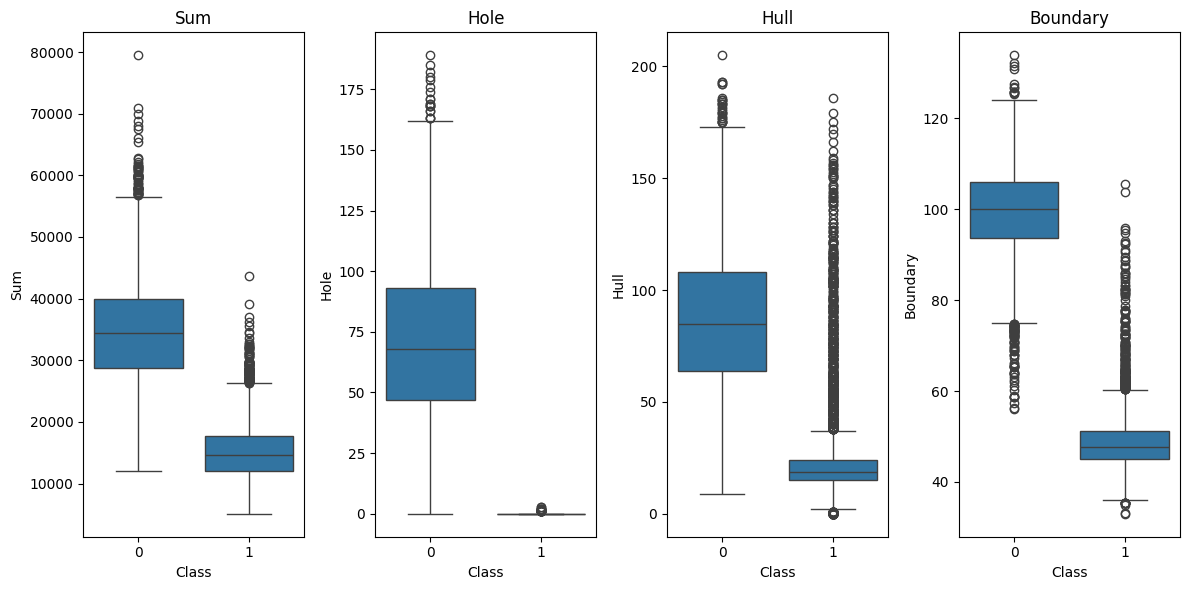

In [ ]:
# Boxplot visualization of each feature
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(X, columns=["Sum","Hole","Hull","Boundary"])
df["Class"] = y

plt.figure(figsize=(12,6))
for i, col in enumerate(["Sum","Hole","Hull","Boundary"]):
    plt.subplot(1,4,i+1)
    sns.boxplot(x="Class", y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

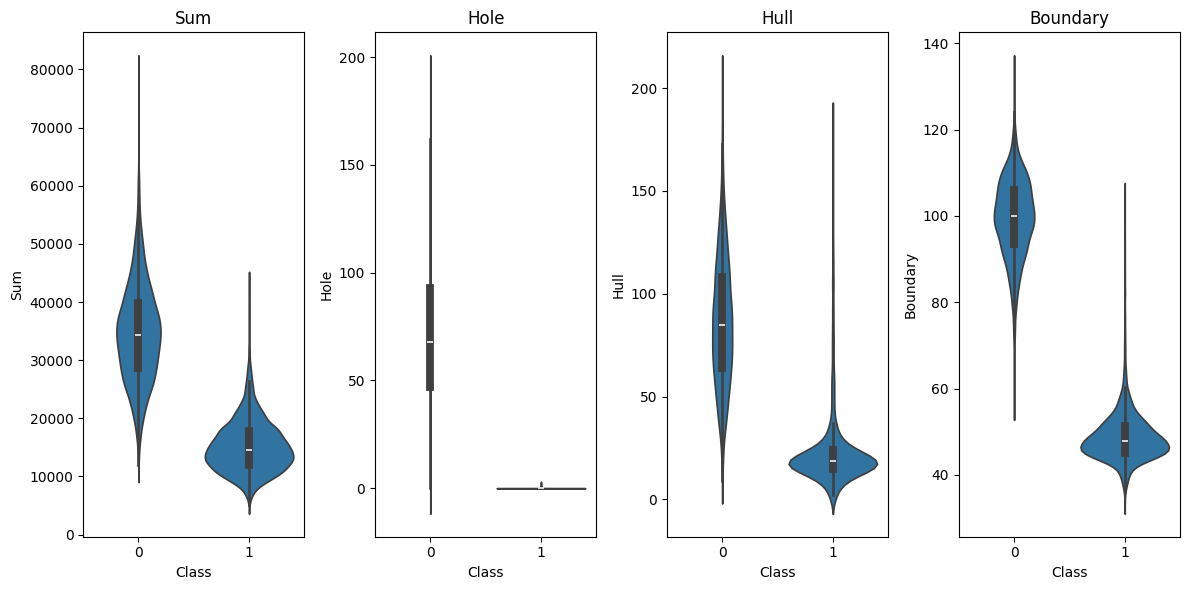

In [ ]:
# Violin plots for feature density visualization
plt.figure(figsize=(12,6))
for i, col in enumerate(["Sum","Hole","Hull","Boundary"]):
    plt.subplot(1,4,i+1)
    sns.violinplot(x="Class", y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Final Conclusion:
# We reduced 784-pixel images into 4 meaningful structural features:
# Sum, Hole, Hull, Boundary.
#
# Single features were weak classifiers.
# Feature combinations significantly improved performance.
# Best pair: Hole + Boundary (~99.44% accuracy).
# Using all 4 features achieved ~99.29% accuracy.
#
# Multi-class classification (0,1,2) achieved ~96.9% accuracy.
#
# This demonstrates that well-designed feature engineering
# can achieve near-deep-learning performance using simple models.